## Inteligência de Escolha de Telefones no WhatsApp

Este Notebook implementa a solução solicitada no case, com foco em transformar logs históricos de disparo em uma regra de negócio acionável para priorização de telefones.

### Problema de negócio

Cada disparo tem custo e existe janela limitada para comunicação com o cidadão. Como o mesmo CPF pode ter múltiplos telefones oriundos de diferentes sistemas, o objetivo é escolher automaticamente os melhores números para maximizar entregas e reduzir custo por entrega.

### O que este Notebook entrega

1. Comparação de qualidade por sistema de origem com taxa e intervalo de confiança
2. Análise de decaimento da qualidade em função do tempo desde última atualização
3. Ranking de sistemas com suavização estatística para evitar conclusões instáveis
4. Algoritmo de score por telefone para escolher os dois melhores telefones por CPF
5. Proposta de experimento A B com hipótese, métricas e amostragem

### Definições operacionais

Sucesso de entrega é definido como `status_disparo` em `delivered` ou `read`. Nesta base, os status estão em minúsculo e `read` implica entrega.

Atualidade é aproximada por `registro_data_atualizacao` em `dim_telefone_mascarado.telefone_aparicoes`.

### Reprodutibilidade

Os Parquets devem estar em `data/raw` conforme instruções do README. Execute o Notebook a partir da raiz do repositório para garantir import do pacote `src`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt


# Garante que o pacote `src` seja importável mesmo se o Jupyter estiver com cwd em `notebooks`
_cwd = Path().resolve()
_repo_root = _cwd if (_cwd / "src").exists() else _cwd.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from src.config import get_paths
from src.io import load_base_disparo, load_dim_telefone
from src.metrics import delivered_flag, aggregate_rate_with_ci
from src.scoring import SystemScoreParams, build_system_ranking, score_phones_for_cpf

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_float("full")

paths = get_paths(_repo_root)
paths

Paths(repo_root=WindowsPath('C:/Users/Nicole Pesoa/OneDrive/Desktop/desafio-tecnico/desafio-cientista-dados-pleno-campanhas'), data_raw=WindowsPath('C:/Users/Nicole Pesoa/OneDrive/Desktop/desafio-tecnico/desafio-cientista-dados-pleno-campanhas/data/raw'), data_processed=WindowsPath('C:/Users/Nicole Pesoa/OneDrive/Desktop/desafio-tecnico/desafio-cientista-dados-pleno-campanhas/data/processed'))

In [2]:
base_lf = load_base_disparo(paths.data_raw)
dim_lf = load_dim_telefone(paths.data_raw)

base_lf.collect_schema(), dim_lf.collect_schema()

(Schema([('id_conta', Int64),
         ('id_hsm', Int64),
         ('id_disparo', Int64),
         ('id_sessao', Int64),
         ('cpf', Int64),
         ('id_target', Int64),
         ('contato_telefone', Int64),
         ('categoria_hsm', String),
         ('ambiente', String),
         ('criacao_envio_datahora', Datetime(time_unit='us', time_zone=None)),
         ('envio_datahora', Datetime(time_unit='us', time_zone=None)),
         ('falha_datahora', Datetime(time_unit='us', time_zone=None)),
         ('descricao_falha', String),
         ('indicador_falha', Boolean),
         ('id_status_disparo', Int64),
         ('status_disparo', String)]),
 Schema([('telefone_ddi', String),
         ('telefone_ddd', Int64),
         ('telefone_numero', Int64),
         ('telefone_tipo', String),
         ('telefone_nacionalidade', String),
         ('telefone_qualidade', String),
         ('telefone_aparicoes',
          List(Struct({'id_sistema': String, 'cpf': Int64, 'proprietario_tipo': St

## Preparação do dataset analítico

A dimensão possui `telefone_aparicoes` como lista de structs. Um mesmo telefone pode aparecer em múltiplos sistemas, cada um com uma data de atualização própria. Para correlacionar sistema de origem com performance real de disparos, precisamos desnormalizar esse campo.

### Estratégia de modelagem

1. Explodir `telefone_aparicoes` para obter uma linha por telefone por sistema
2. Fazer join com a base de disparos usando o telefone como chave
3. Resolver o problema de multiplicidade do join. Um disparo pode casar com múltiplas linhas da dimensão, porque o telefone tem várias aparições

### Regra de seleção do sistema por disparo

Para cada `id_disparo`, escolhemos um único sistema representativo para atribuição de origem.

Critério

1. Preferir aparições com `registro_data_atualizacao` menor ou igual à data do envio, pois são temporalmente consistentes
2. Entre as consistentes, escolher a maior `registro_data_atualizacao`, pois representa o dado mais recente no momento do envio
3. Se nenhuma aparição for consistente, manter a mais recente disponível como fallback

Essa regra evita inflar a contagem do disparo em múltiplos sistemas ao mesmo tempo e torna as métricas por sistema comparáveis.

In [3]:
dim_aparicoes = (
    dim_lf
    .with_columns(telefone_mascarado=pl.col("telefone_numero"))
    .select(
        "telefone_numero",
        "telefone_ddi",
        "telefone_ddd",
        "telefone_tipo",
        "telefone_nacionalidade",
        "telefone_qualidade",
        "telefone_aparicoes",
        "telefone_aparicoes_quantidade",
        "telefone_proprietarios_quantidade",
        "telefone_sistemas_quantidade",
        "validacao_telefone",
    )
    .explode("telefone_aparicoes")
    .unnest("telefone_aparicoes")
    .rename(
        {
            "telefone_numero": "telefone_mascarado",
            "id_sistema": "id_sistema_mask",
            "registro_data_atualizacao": "registro_data_atualizacao",
            "cpf": "cpf_aparicao",
        }
    )
)

dim_aparicoes.collect_schema()

Schema([('telefone_mascarado', Int64),
        ('telefone_ddi', String),
        ('telefone_ddd', Int64),
        ('telefone_tipo', String),
        ('telefone_nacionalidade', String),
        ('telefone_qualidade', String),
        ('id_sistema_mask', String),
        ('cpf_aparicao', Int64),
        ('proprietario_tipo', String),
        ('registro_data_atualizacao', Date),
        ('telefone_aparicoes_quantidade', Int64),
        ('telefone_proprietarios_quantidade', Int64),
        ('telefone_sistemas_quantidade', Int64),
        ('validacao_telefone',
         Struct({'ddd_valido_br': Boolean, 'formato_valido': Boolean, 'padrao_suspeito': Boolean, 'padrao_invalido': Boolean}))])

In [4]:
base_enriched = (
    base_lf
    .with_columns(
        delivered=delivered_flag(pl.col("status_disparo")),
        envio_data=pl.col("envio_datahora").dt.date(),
    )
    .join(
        dim_aparicoes,
        left_on="contato_telefone",
        right_on="telefone_mascarado",
        how="left",
    )
    .with_columns(
        registro_data_atualizacao=pl.col("registro_data_atualizacao").cast(pl.Date),
        registro_valido_no_envio=(pl.col("registro_data_atualizacao") <= pl.col("envio_data")),
    )
)

base_enriched.select(
    "id_disparo",
    "contato_telefone",
    "status_disparo",
    "delivered",
    "envio_datahora",
    "envio_data",
    "id_sistema_mask",
    "registro_data_atualizacao",
    "registro_valido_no_envio",
).head(5).collect()

id_disparo,contato_telefone,status_disparo,delivered,envio_datahora,envio_data,id_sistema_mask,registro_data_atualizacao,registro_valido_no_envio
i64,i64,str,i8,datetime[μs],date,str,date,bool
-2317524427909960986,2824089259510570290,"""processing""",0,2025-10-07 13:15:17.204,2025-10-07,null,null,null
-6855906542267037066,-4599056651977889342,"""processing""",0,2025-10-25 10:56:45.028,2025-10-25,"""3094574413675758272""",2024-05-16,true
-6855906542267037066,-4599056651977889342,"""processing""",0,2025-10-25 10:56:45.028,2025-10-25,"""-133612832286195827""",null,null
-6855906542267037066,-4599056651977889342,"""processing""",0,2025-10-25 10:56:45.028,2025-10-25,"""-133612832286195827""",null,null
-6855906542267037066,-4599056651977889342,"""processing""",0,2025-10-25 10:56:45.028,2025-10-25,"""3094574413675758272""",2024-05-16,true


In [5]:
def select_system_for_event(lf: pl.LazyFrame) -> pl.LazyFrame:
    by_event = ["id_disparo"]

    candidates = (
        lf.with_columns(
            prefer=pl.when(pl.col("registro_valido_no_envio")).then(1).otherwise(0),
            recency=pl.col("registro_data_atualizacao"),
        )
        .sort(by_event + ["prefer", "recency"], descending=[False, True, True])
        .group_by(by_event)
        .first()
    )

    out = candidates.with_columns(
        age_days=(pl.col("envio_data") - pl.col("registro_data_atualizacao")).dt.total_days().cast(pl.Float64)
    )
    return out


events = select_system_for_event(base_enriched)

events.select(
    "id_disparo",
    "cpf",
    "contato_telefone",
    "id_sistema_mask",
    "registro_data_atualizacao",
    "envio_data",
    "age_days",
    "status_disparo",
    "delivered",
).head(5).collect()

id_disparo,cpf,contato_telefone,id_sistema_mask,registro_data_atualizacao,envio_data,age_days,status_disparo,delivered
i64,i64,i64,str,date,date,f64,str,i8
-9223351916581235936,5390755073247433751,4064757259083255873,"""1257277410380486863""",2025-11-01,2025-11-14,13,"""read""",1
-9223347553164632852,5727544527556597460,-5404120253297123491,"""-4704067261970591609""",2025-09-17,2025-12-12,86,"""read""",1
-9223331842594794498,2813023447562084872,2524702099694199688,"""3094574413675758272""",2025-10-02,2026-02-24,145,"""delivered""",1
-9223306595261143748,8905631595966597322,-19350203587627911,"""-4704067261970591609""",2025-06-18,2025-11-12,147,"""read""",1
-9223245723759412697,1818393646559723337,7546684854071138548,"""-4704067261970591609""",2025-10-31,2026-02-21,113,"""read""",1


## Parte 1.1 Taxa de entrega por sistema de origem

Métrica principal

Taxa de entrega por tentativa

\(p = \frac{\#DELIVERED}{\#tentativas}\)

Para evitar conclusões frágeis em sistemas com pouco volume, reporto intervalo de confiança de Wilson para proporção binária.

In [6]:
events_df = events.select(
    "id_disparo",
    "cpf",
    "contato_telefone",
    "id_sistema_mask",
    "registro_data_atualizacao",
    "envio_datahora",
    "envio_data",
    "age_days",
    "telefone_ddi",
    "telefone_ddd",
    "telefone_tipo",
    "telefone_qualidade",
    "validacao_telefone",
    "status_disparo",
    "delivered",
).collect()

rates_system = (
    aggregate_rate_with_ci(
        events_df.filter(pl.col("id_sistema_mask").is_not_null()),
        group_cols=["id_sistema_mask"],
        success_col="delivered",
    )
    .sort(["rate", "n"], descending=True)
)

rates_system.head(20)

id_sistema_mask,n,rate,ci_low,ci_high
str,u32,f64,f64,f64
"""-4704067261970591609""",116239,0.9861062122007244,0.9854170769060052,0.986763218945019
"""-2757366171786647144""",2476,0.9450726978998385,0.9353894578333702,0.9533770365570121
"""3094574413675758272""",154881,0.9346272299378232,0.9333853939214934,0.9358475066770741
"""1257277410380486863""",55533,0.8837087857670214,0.8810159567916866,0.88634853280752
"""4458959843028638627""",2832,0.8675847457627118,0.8546021216062591,0.879571502072201
"""-133612832286195827""",13070,0.6671002295332823,0.6589730759576128,0.6751291857042024


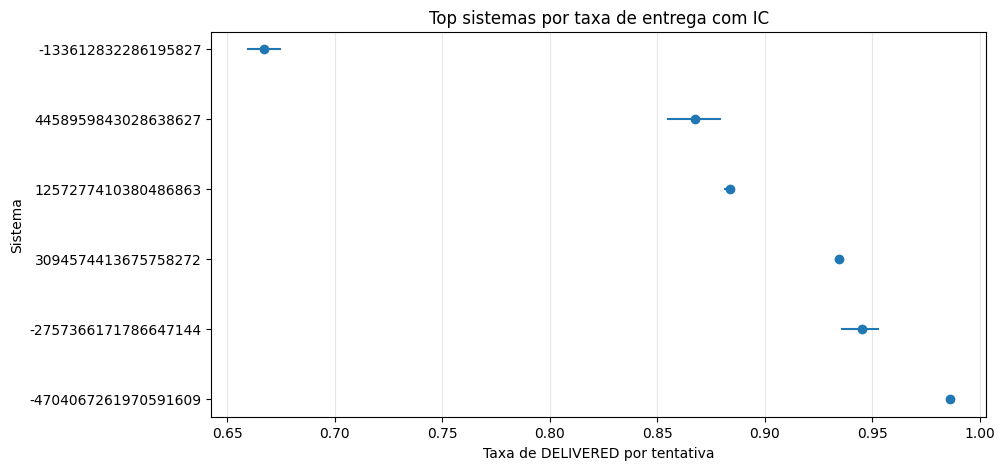

In [7]:
topk = rates_system.head(15)

x = topk.get_column("rate").to_numpy()
low = topk.get_column("ci_low").to_numpy()
high = topk.get_column("ci_high").to_numpy()

left = x - low
right = high - x

left = np.where(np.isfinite(left), left, 0.0)
right = np.where(np.isfinite(right), right, 0.0)

left = np.maximum(0.0, left)
right = np.maximum(0.0, right)

plt.figure(figsize=(10, 5))
plt.errorbar(
    x=x,
    y=topk.get_column("id_sistema_mask").to_list(),
    xerr=[left, right],
    fmt="o",
)
plt.xlabel("Taxa de DELIVERED por tentativa")
plt.ylabel("Sistema")
plt.title("Top sistemas por taxa de entrega com IC")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## Viés de seleção e leitura correta das taxas

Alguns sistemas aparecem mais no log porque já são usados como fonte prioritária. Isso gera viés de seleção, pois o conjunto de telefones tentados por cada sistema pode ser diferente em qualidade intrínseca.

### Risco

Um sistema pode parecer melhor apenas porque foi usado em um subconjunto de telefones mais fáceis, ou porque recebeu mais tentativas em diferentes momentos.

### Mitigação prática nesta entrega

1. Reportar volume de tentativas por sistema junto da taxa e do intervalo de confiança
2. Recalcular as taxas em um subconjunto mais comparável, telefones que aparecem em dois ou mais sistemas

Leitura recomendada

O ranking mede associação observada entre sistema e sucesso sob controles simples. Para inferência causal, seria necessário um desenho experimental ou uma estratégia de identificação.

In [8]:
phone_systems = (
    dim_lf
    .select(
        telefone_mascarado=pl.col("telefone_numero"),
        telefone_sistemas_quantidade=pl.col("telefone_sistemas_quantidade"),
    )
)

events_df2 = (
    events_df.lazy()
    .join(phone_systems, left_on="contato_telefone", right_on="telefone_mascarado", how="left")
    .collect()
)

rates_system_multi = (
    aggregate_rate_with_ci(
        events_df2.filter(pl.col("telefone_sistemas_quantidade") >= 2),
        group_cols=["id_sistema_mask"],
        success_col="delivered",
    )
    .sort(["rate", "n"], descending=True)
)

rates_system.join(
    rates_system_multi.rename({"n": "n_multi", "rate": "rate_multi", "ci_low": "ci_low_multi", "ci_high": "ci_high_multi"}),
    on="id_sistema_mask",
    how="left",
).select(
    "id_sistema_mask",
    "n",
    "rate",
    "ci_low",
    "ci_high",
    "n_multi",
    "rate_multi",
    "ci_low_multi",
    "ci_high_multi",
).head(20)

id_sistema_mask,n,rate,ci_low,ci_high,n_multi,rate_multi,ci_low_multi,ci_high_multi
str,u32,f64,f64,f64,u32,f64,f64,f64
"""-4704067261970591609""",116239,0.9861062122007244,0.9854170769060052,0.986763218945019,95712,0.9852996489468405,0.9845174857882463,0.9860428580809241
"""-2757366171786647144""",2476,0.9450726978998385,0.9353894578333702,0.9533770365570121,2036,0.9587426326129665,0.9492047805246587,0.9665526632327389
"""3094574413675758272""",154881,0.9346272299378232,0.9333853939214934,0.9358475066770741,117832,0.9634819064430715,0.9623957008035331,0.964537892980583
"""1257277410380486863""",55533,0.8837087857670214,0.8810159567916866,0.88634853280752,28312,0.923919186210794,0.9207730642895982,0.9269502864329529
"""4458959843028638627""",2832,0.8675847457627118,0.8546021216062591,0.879571502072201,2053,0.9035557720409158,0.8900223939770062,0.9155817486728866
"""-133612832286195827""",13070,0.6671002295332823,0.6589730759576128,0.6751291857042024,2332,0.8619210977701544,0.8473230400060262,0.8753287451250705


## Parte 1.2 Janela de atualidade e decaimento

Definição operacional

Idade do dado no envio em dias

\(age\_days = envio\_data - registro\_data\_atualizacao\)

O objetivo é observar se a probabilidade de entrega decai com o tempo e estimar um prazo de validade prático para considerar um telefone quente.

In [9]:
events_decay = (
    events_df.filter(pl.col("age_days").is_not_null())
    .with_columns(age_days=pl.when(pl.col("age_days") < 0).then(0.0).otherwise(pl.col("age_days")))
    .with_columns(
        age_bucket=pl.col("age_days").cut(
            breaks=[7, 30, 90, 180, 365, 730],
            labels=["0_7", "7_30", "30_90", "90_180", "180_365", "365_730", "730_plus"],
        )
    )
)

rates_age = (
    aggregate_rate_with_ci(events_decay, group_cols=["age_bucket"], success_col="delivered")
    .with_columns(
        age_bucket=pl.col("age_bucket").cast(pl.Utf8),
        age_bucket_order=pl.col("age_bucket").replace(
            {
                "0_7": 0,
                "7_30": 1,
                "30_90": 2,
                "90_180": 3,
                "180_365": 4,
                "365_730": 5,
                "730_plus": 6,
            }
        ),
    )
    .sort("age_bucket_order")
)

rates_age.select("age_bucket", "n", "rate", "ci_low", "ci_high")

age_bucket,n,rate,ci_low,ci_high
str,u32,f64,f64,f64
"""0_7""",1313,0.9748667174409749,0.9649143905551374,0.9820485043682643
"""7_30""",6248,0.9748719590268886,0.970689524159731,0.9784708214897492
"""30_90""",27628,0.9679310844071232,0.96578767317403,0.9699443893645017
"""90_180""",200996,0.9761736551971183,0.975497774108712,0.9768313352613381
"""180_365""",37042,0.8788402354084552,0.8754778557050462,0.882124047634024
"""365_730""",31881,0.8679777924155453,0.8642175531497763,0.8716493643728492
"""730_plus""",26300,0.8486311787072244,0.8442486852749116,0.8529118427304214


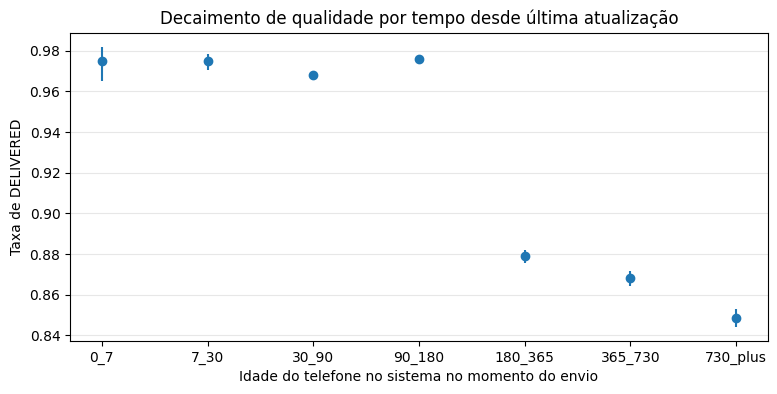

In [10]:
x = rates_age.get_column("age_bucket").to_list()
y = rates_age.get_column("rate").to_numpy()
low = rates_age.get_column("ci_low").to_numpy()
high = rates_age.get_column("ci_high").to_numpy()

down = y - low
up = high - y

down = np.where(np.isfinite(down), down, 0.0)
up = np.where(np.isfinite(up), up, 0.0)

down = np.maximum(0.0, down)
up = np.maximum(0.0, up)

plt.figure(figsize=(9, 4))
plt.errorbar(
    x=x,
    y=y,
    yerr=[down, up],
    fmt="o",
)
plt.xlabel("Idade do telefone no sistema no momento do envio")
plt.ylabel("Taxa de DELIVERED")
plt.title("Decaimento de qualidade por tempo desde última atualização")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [11]:
import statsmodels.api as sm

# Ajuste logístico direto pode sofrer com PerfectSeparation em grandes bases.
# Para obter um efeito de decaimento interpretável e estável, agrego por bins de idade
# e ajusto um GLM binomial com pesos e regularização.
#
# Observação importante
# Para estabilidade numérica, padronizo age_days, pois valores muito altos podem causar overflow na função logística.

reg_df = (
    events_decay.select("delivered", "age_days")
    .drop_nulls()
    .with_columns(age_days=pl.col("age_days").clip(0, 2000))
    .with_columns(age_bin=pl.col("age_days").qcut(50, labels=None, allow_duplicates=True))
    .group_by("age_bin")
    .agg(
        age_days=pl.col("age_days").mean(),
        n=pl.len(),
        successes=pl.col("delivered").sum(),
    )
    .with_columns(
        # proporção com suavização para evitar 0 e 1 exatos
        p=(pl.col("successes") + 0.5) / (pl.col("n") + 1.0)
    )
    .sort("age_days")
).to_pandas()

age_mean = float(reg_df["age_days"].mean())
age_std = float(reg_df["age_days"].std(ddof=0))
reg_df["age_scaled"] = (reg_df["age_days"].astype(float) - age_mean) / max(age_std, 1e-12)

X = sm.add_constant(reg_df["age_scaled"].astype(float))
y = reg_df["p"].astype(float)

# var_weights representa o numero de tentativas por observacao de proporcao
w = reg_df["n"].astype(float)

model = sm.GLM(y, X, family=sm.families.Binomial(), var_weights=w)
res = model.fit_regularized(alpha=1e-4, L1_wt=0.0)

{"params": res.params.to_dict(), "age_mean": age_mean, "age_std": age_std}

{'params': {'const': 2.861954414375184, 'age_scaled': -0.5368873159352628},
 'age_mean': 330.7977016958526,
 'age_std': 392.75497598020337}

In [12]:
b_scaled = float(res.params["age_scaled"])

# converte o coeficiente da escala padronizada para coeficiente por dia
b_per_day = b_scaled / max(age_std, 1e-12)

if b_per_day >= 0:
    half_life_odds = np.inf
else:
    half_life_odds = float(np.log(0.5) / b_per_day)

{"b_per_day": b_per_day, "half_life_odds_days": half_life_odds}

{'b_per_day': -0.0013669777565398036,
 'half_life_odds_days': 507.06544217258613}

## Parte 2.1 Ranking de sistemas

Construção do score

Para cada sistema

1. Contar tentativas \(n\) e entregas \(s\)
2. Estimar uma taxa suavizada via média a posteriori Beta

\[\hat p = \frac{s + \alpha}{n + \alpha + \beta}\]

Isso reduz instabilidade em sistemas com baixo volume.

Depois aplico um encolhimento adicional por volume para reduzir ranking inflado por amostras pequenas

\[score = \hat p \cdot \frac{n}{n + k}\]

com \(k\) constante de regularização.

In [13]:
system_rank = build_system_ranking(
    df_events=events_decay.drop_nulls(["id_sistema_mask"]),
    system_col="id_sistema_mask",
    delivered_col="delivered",
    age_days_col="age_days",
    params=SystemScoreParams(prior_alpha=2.0, prior_beta=2.0, half_life_days=float(half_life_odds) if np.isfinite(half_life_odds) else 365.0),
)

system_rank.head(30)

id_sistema_mask,n,successes,mean_age_days,posterior_mean,score
str,u32,i64,f64,f64,f64
"""-4704067261970591609""",116239,114624,124.63212863152643,0.986089484958234,0.9818660057226819
"""3094574413675758272""",154881,144756,253.07526423512246,0.9346160054233786,0.9316085077067229
"""1257277410380486863""",52225,46385,665.1138343705122,0.8881464320588179,0.8797239907875157
"""-2757366171786647144""",2476,2340,328.16033925686594,0.9443548387096774,0.7856930714533472
"""4458959843028638627""",2832,2457,319.51871468926555,0.8670662905500706,0.7369543021722088
"""-133612832286195827""",2755,2303,779.2656987295826,0.8354476259514316,0.7071146572952977


## Parte 2.2 Algoritmo de escolha dos dois melhores telefones por CPF

Objetivo

Dado um CPF com múltiplos telefones candidatos, retornar os dois com maior probabilidade de entrega.

Score por telefone

\[final\_score = system\_score \cdot recency\_weight(age\_days) \cdot ddd\_factor\]

Onde

1. `system_score` vem do ranking anterior
2. `recency_weight` usa decaimento exponencial com meia vida em dias

\[recency\_weight = 2^{-age\_days / half\_life}\]

3. `ddd_factor` é um ajuste opcional por desempenho histórico do DDD ou por validações estruturais

Decisão

Ordenar os telefones pelo `final_score` e escolher os dois maiores

In [14]:
ddd_rates = (
    events_df.filter(pl.col("telefone_ddd").is_not_null())
    .group_by("telefone_ddd")
    .agg(n=pl.len(), rate=pl.col("delivered").mean())
    .filter(pl.col("n") >= 200)
    .sort("rate", descending=True)
)

q_low = float(ddd_rates.get_column("rate").quantile(0.2)) if ddd_rates.height else 0.0
q_high = float(ddd_rates.get_column("rate").quantile(0.8)) if ddd_rates.height else 0.0

bonus_map = {}
for row in ddd_rates.select(["telefone_ddd", "rate"]).to_dicts():
    ddd = str(row["telefone_ddd"])
    r = float(row["rate"])
    if r >= q_high:
        bonus_map[ddd] = 0.05
    elif r <= q_low:
        bonus_map[ddd] = -0.05

params = SystemScoreParams(
    prior_alpha=2.0,
    prior_beta=2.0,
    half_life_days=float(half_life_odds) if np.isfinite(half_life_odds) else 365.0,
    ddd_bonus=bonus_map,
)

len(bonus_map), list(bonus_map.items())[:5]

(4,
 [('-1181433720517268842', 0.05),
  ('2685248380958544781', 0.05),
  ('1110362451252208393', -0.05),
  ('-4523905025782287081', -0.05)])

In [15]:
dim_candidates = (
    dim_aparicoes
    .select(
        cpf=pl.col("cpf_aparicao"),
        telefone=pl.col("telefone_mascarado"),
        id_sistema_mask=pl.col("id_sistema_mask"),
        registro_data_atualizacao=pl.col("registro_data_atualizacao"),
        telefone_ddd=pl.col("telefone_ddd"),
    )
    .drop_nulls(["cpf", "telefone", "id_sistema_mask", "registro_data_atualizacao"])
)

cpf_exemplo = int(dim_candidates.select("cpf").limit(1).collect().item())

cand_df = dim_candidates.filter(pl.col("cpf") == cpf_exemplo).collect()

now_ts = pd.Timestamp("2026-04-27")

scored = score_phones_for_cpf(
    df_candidates=cand_df,
    system_rank=system_rank,
    system_col="id_sistema_mask",
    phone_col="telefone",
    updated_at_col="registro_data_atualizacao",
    ddd_col="telefone_ddd",
    now_ts=now_ts,
    params=params,
)

scored.head(10)

telefone,id_sistema_mask,registro_data_atualizacao,telefone_ddd,final_score,rank
i64,str,date,i64,f64,i64
-6862804366069381626,"""1257277410380486863""",2024-10-30,-1181433720517268842,0.43911549983899667,1


In [16]:
cpfs_multi = (
    dim_candidates
    .group_by("cpf")
    .agg(n_telefones=pl.col("telefone").n_unique())
    .filter(pl.col("n_telefones") >= 3)
    .sort("n_telefones", descending=True)
    .collect()
)

cpf_exemplo = int(cpfs_multi[0, "cpf"])
cpf_exemplo

5439497641908800296

In [17]:
scored.filter(pl.col("rank") <= 2)

telefone,id_sistema_mask,registro_data_atualizacao,telefone_ddd,final_score,rank
i64,str,date,i64,f64,i64
-6862804366069381626,"""1257277410380486863""",2024-10-30,-1181433720517268842,0.43911549983899667,1


In [18]:
cand_df = dim_candidates.filter(pl.col("cpf") == cpf_exemplo).collect()

cand_df.height, cand_df.select(pl.col("telefone").n_unique()).item()

(398, 398)

## Notas de execução e troubleshooting

### Import do pacote src

Se aparecer `ModuleNotFoundError: No module named 'src'`, o motivo usual é o Jupyter com diretório atual em `notebooks`. Este Notebook injeta o caminho do repositório no `sys.path` na primeira célula de código. Se você executou fora de ordem, reinicie o kernel e rode tudo.

### Barras de erro negativas em gráficos

O Matplotlib não aceita `xerr` ou `yerr` negativos. As células de gráfico saturam os erros em zero e tratam valores ausentes para garantir execução reprodutível.

### Estabilidade numérica no decaimento

Em bases grandes, regressão logística linha a linha pode sofrer instabilidade. A etapa de decaimento agrega por bins e usa padronização para melhorar estabilidade. O objetivo é interpretar a tendência de decaimento e produzir um parâmetro operacional de meia vida.

In [19]:
scored = score_phones_for_cpf(
    df_candidates=cand_df,
    system_rank=system_rank,
    system_col="id_sistema_mask",
    phone_col="telefone",
    updated_at_col="registro_data_atualizacao",
    ddd_col="telefone_ddd",
    now_ts=pd.Timestamp("2026-04-27"),
    params=params,
)

scored, scored.filter(pl.col("rank") <= 2)

(shape: (398, 6)
 ┌──────────────────────┬──────────────────────┬──────────────────────┬─────────────────────┬────────────────────┬──────┐
 │ telefone             ┆ id_sistema_mask      ┆ registro_data_atuali ┆ telefone_ddd        ┆ final_score        ┆ rank │
 │ ---                  ┆ ---                  ┆ zacao                ┆ ---                 ┆ ---                ┆ ---  │
 │ i64                  ┆ str                  ┆ ---                  ┆ i64                 ┆ f64                ┆ i64  │
 │                      ┆                      ┆ date                 ┆                     ┆                    ┆      │
 ╞══════════════════════╪══════════════════════╪══════════════════════╪═════════════════════╪════════════════════╪══════╡
 │ 3016038700791482361  ┆ -4704067261970591609 ┆ 2025-11-15           ┆ -118143372051726884 ┆ 0.8250365088552973 ┆ 1    │
 │                      ┆                      ┆                      ┆ 2                   ┆                    ┆      │
 │ 2516

In [20]:
scored.filter(pl.col("rank") <= 10).select("telefone").n_unique()

10

In [21]:
top2_telefones = (
    scored
    .group_by("telefone")
    .agg(
        final_score=pl.col("final_score").max(),
        registro_data_atualizacao=pl.col("registro_data_atualizacao").max(),
        id_sistema_mask=pl.col("id_sistema_mask").first(),
        telefone_ddd=pl.col("telefone_ddd").first(),
    )
    .sort("final_score", descending=True)
    .head(2)
)

top2_telefones

telefone,final_score,registro_data_atualizacao,id_sistema_mask,telefone_ddd
i64,f64,date,str,i64
-117014160379137149,0.8250365088552973,2025-11-15,"""-4704067261970591609""",-1181433720517268842
3016038700791482361,0.8250365088552973,2025-11-15,"""-4704067261970591609""",-1181433720517268842


In [22]:
top2 = scored.filter(pl.col("rank") <= 2)

top2.select(
    pl.col("telefone").n_unique().alias("telefones_distintos"),
    pl.len().alias("linhas_top2"),
)

telefones_distintos,linhas_top2
u32,u32
2,2


## Parte 3 Desenho de experimento A B

Objetivo

Validar se a estratégia de priorização melhora entrega e reduz custo por entrega em comparação com a estratégia atual de baseline.

Unidade de randomização

CPF para evitar interferência entre telefones do mesmo cidadão.

Tratamentos

Controle

Selecionar aleatoriamente dois telefones elegíveis do CPF

Tratamento

Selecionar os dois telefones com maior `final_score`

Hipótese nula

\(H_0\) a taxa de entrega do tratamento é menor ou igual à do controle

\(p_T \le p_C\)

Hipótese alternativa

\(H_1\) a taxa de entrega do tratamento é maior

\(p_T > p_C\)

Métrica primária

Taxa de DELIVERED por CPF ao menos uma entrega nas duas tentativas

Métricas secundárias

1. Taxa de DELIVERED por tentativa
2. Custo por entrega proxy \(2\) tentativas dividido por entregas
3. Taxa de falhas por motivo `descricao_falha` quando disponível
4. Tempo até resposta quando existir

Guardrails

1. Taxa de bloqueio ou padrão suspeito se existir via validação
2. Reclamação ou opt out se houver no produto

In [23]:
from math import ceil
from scipy.stats import norm


def sample_size_two_proportions(p_c: float, p_t: float, alpha: float = 0.05, power: float = 0.8) -> int:
    if not (0 < p_c < 1 and 0 < p_t < 1):
        return 0
    z_alpha = float(norm.ppf(1 - alpha))
    z_beta = float(norm.ppf(power))
    p_bar = (p_c + p_t) / 2

    num = (z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) + z_beta * np.sqrt(p_c * (1 - p_c) + p_t * (1 - p_t))) ** 2
    den = (p_t - p_c) ** 2
    return int(ceil(num / den))


baseline_p = float(events_df.select(pl.col("delivered").mean()).item())

desired_abs_lift = 0.01  # exemplo: +1 ponto percentual
p_t = min(0.99, baseline_p + desired_abs_lift)

n_per_group = sample_size_two_proportions(baseline_p, p_t, alpha=0.05, power=0.8)

baseline_p, p_t, n_per_group

(0.9085057810603149, 0.9185057810603149, 9769)

### Duração estimada

Dado um volume diário \(V\) de CPFs elegíveis por dia, a duração aproximada em dias é

\[dias \approx \frac{2 \cdot n\_per\_group}{V}\]

O fator \(2\) é porque precisamos preencher controle e tratamento.

Recomendação operacional

1. Rodar de uma a duas semanas no mínimo para capturar ciclos de uso do WhatsApp e sazonalidade de dia da semana
2. Monitorar diariamente as métricas primárias e guardrails
3. Congelar a regra do ranking durante o teste para evitar contaminação